## Lab 4: Generating CDFs

**Names:** Hannah Sweazey, Hannah Dykens, Tejas Reddy

In [69]:
import numpy as np
import random
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

In [70]:
def ecdf_xy(samples):
    x = np.sort(np.asarray(samples))
    y = np.arange(1, len(x) + 1) / len(x)
    return x, y


def plot_ecdf_vs_cdf(samples, cdf, grid=None, title="", xlabel="", discrete=False, logx=False):
    x, y = ecdf_xy(samples)
    fig, ax = plt.subplots()
    ax.step(x, y, where="post", lw=2, label="simulation ECDF")

    if grid is None:
        lo, hi = np.quantile(x, [0.001, 0.999])
        grid = np.linspace(lo, hi, 400)
    if discrete:
        ax.step(grid, cdf(grid), where="post", lw=2, label="scipy CDF")
    else:
        ax.plot(grid, cdf(grid), lw=2, label="scipy CDF")

    if logx:
        ax.set_xscale("log")
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("cumulative probability")
    ax.legend()
    return ax


def show_quantiles(samples, dist, probs=(0.1, 0.25, 0.5, 0.75, 0.9)):
    return pd.DataFrame({
        "p": probs,
        "simulation": np.quantile(samples, probs),
        "scipy": dist.ppf(probs),
    })

## Q1.

1.

In [ ]:
K = 5
grid = np.linspace(0, 1, K)

np.float64(0.0)

2.

In [ ]:
random_value_from_grid = np.random.choice(grid)
random_value_from_grid

3.

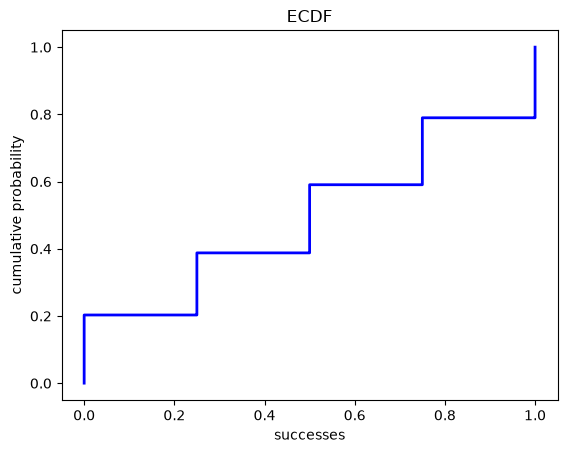

In [72]:
#ECDF with n = 5000 and K = 1
N = K
pA = np.ones(K) /K
rng = np.random.default_rng()
sampleA = rng.choice(a = grid, size = 5000, p = pA)

#left plot: ECDF plot
x, y = ecdf_xy(sampleA)  
plt.step(x, y, where='post', color='blue', lw=2, label=f"p = {pA}, sample proportion = {sampleA.mean():.3f}")
plt.title("ECDF")
plt.xlabel("successes")
plt.ylabel("cumulative probability")
plt.show()

4.

In [73]:
K = 100
grid = np.linspace(0, 1, K)
random_value_from_grid = np.random.choice(grid)
random_value_from_grid

np.float64(0.0)

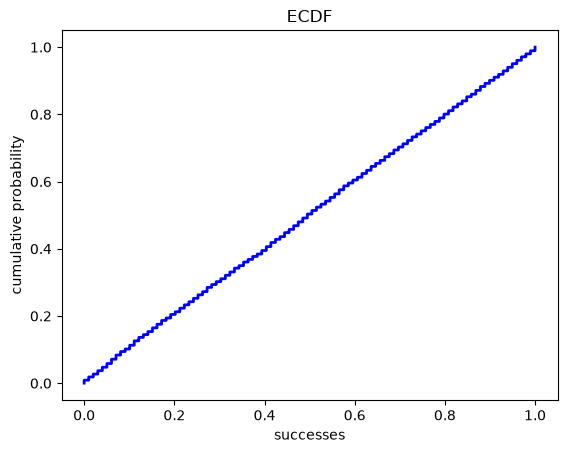

In [74]:
#ECDF with n = 5000 and K = 100
N = K
pA = np.ones(K) /K
rng = np.random.default_rng()
sampleA = rng.choice(a = grid, size = 5000, p = pA)

#left plot: ECDF plot
x, y = ecdf_xy(sampleA)  
plt.step(x, y, where='post', color='blue', lw=2, label=f"p = {pA}, sample proportion = {sampleA.mean():.3f}")
plt.title("ECDF")
plt.xlabel("successes")
plt.ylabel("cumulative probability")
plt.show()

In [75]:
K = 10000
grid = np.linspace(0, 1, K)
random_value_from_grid = np.random.choice(grid)
random_value_from_grid

np.float64(0.3799379937993799)

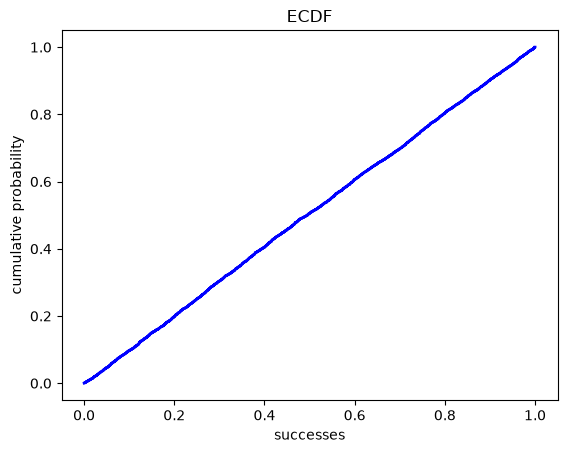

In [76]:
#ECDF with n = 5000 and K = 10,000
N = K
pA = np.ones(K) /K
rng = np.random.default_rng()
sampleA = rng.choice(a = grid, size = 5000, p = pA)

#left plot: ECDF plot
x, y = ecdf_xy(sampleA)  
plt.step(x, y, where='post', color='blue', lw=2, label=f"p = {pA}, sample proportion = {sampleA.mean():.3f}")
plt.title("ECDF")
plt.xlabel("successes")
plt.ylabel("cumulative probability")
plt.show()


As you increase $K$, the distribution approaches a uniform distribution.

## Q2.


1.

In [ ]:
N = 32

sampleA = rng.uniform((np.sqrt(3)* -1), np.sqrt(3), size= N)

trial_pathsA = sampleA.mean()

print(sampleA)
print(trial_pathsA)

[-1.46052517  0.65043787 -0.02882572  0.53071368 -1.56906028 -0.37853627
 -1.34818694  1.06582704  1.65825197 -1.01625147 -0.22376218 -1.20546993
 -1.45552713 -0.13993983 -1.28667675  1.42979009  0.0568915  -1.36646262
  0.55528744 -0.97695882 -1.13817428  0.28048588  0.95965843 -1.55787945
  1.71353887 -0.83457717 -1.19505923 -0.28484511  1.70084314 -0.16270701
  1.07043399  1.4449142 ]
-0.14101097694783438


2.

In [78]:
trial_pathsA * np.sqrt(N)

np.float64(-0.797678544172429)

3.

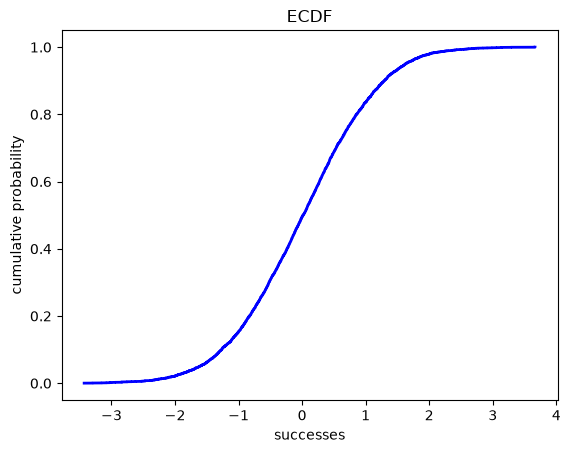

In [79]:
rng = np.random.default_rng()
sampleA = rng.uniform((np.sqrt(3)* -1), np.sqrt(3), size = [5000,32])

mean_of_everything = np.mean(sampleA, axis=1) * np.sqrt(N)

#left plot: ECDF plot
x, y = ecdf_xy(mean_of_everything)  
plt.step(x, y, where='post', color='blue', lw=2)
plt.title("ECDF")
plt.xlabel("successes")
plt.ylabel("cumulative probability")
plt.show()

4.

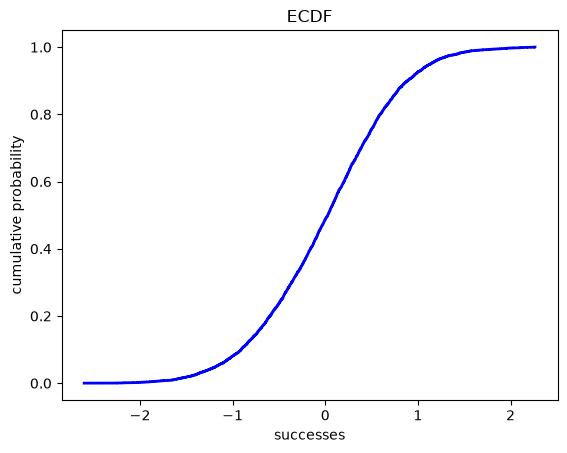

In [80]:
rng = np.random.default_rng()
sampleA = rng.uniform((np.sqrt(3)* -1), np.sqrt(3), size = [5000,64])

mean_of_everything = np.mean(sampleA, axis=1) * np.sqrt(N)

#left plot: ECDF plot
x, y = ecdf_xy(mean_of_everything)  
plt.step(x, y, where='post', color='blue', lw=2)
plt.title("ECDF")
plt.xlabel("successes")
plt.ylabel("cumulative probability")
plt.show()

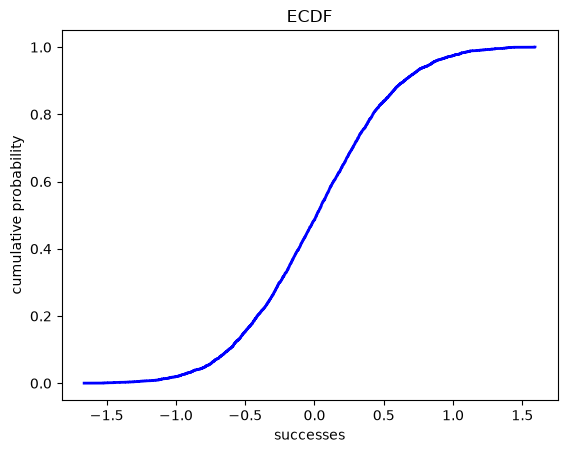

In [81]:
rng = np.random.default_rng()
sampleA = rng.uniform((np.sqrt(3)* -1), np.sqrt(3), size = [5000,128])

mean_of_everything = np.mean(sampleA, axis=1) * np.sqrt(N)

#left plot: ECDF plot
x, y = ecdf_xy(mean_of_everything)  
plt.step(x, y, where='post', color='blue', lw=2)
plt.title("ECDF")
plt.xlabel("successes")
plt.ylabel("cumulative probability")
plt.show()

As $n$ increases, this more closely approaches a normal distribution and the x axis range condenses.

## Q3.

1.

In [96]:
n = 40
p = 0.5

# count of heads/successes
heads = rng.binomial(n=n, p=p)

heads

15

2. & 3.

In [97]:
# subtracting expected number of heads and divide by standard deviation
zscore = (heads - (n*p)) / np.sqrt((n*p*(1-p)))

zscore

np.float64(-1.5811388300841895)

4.

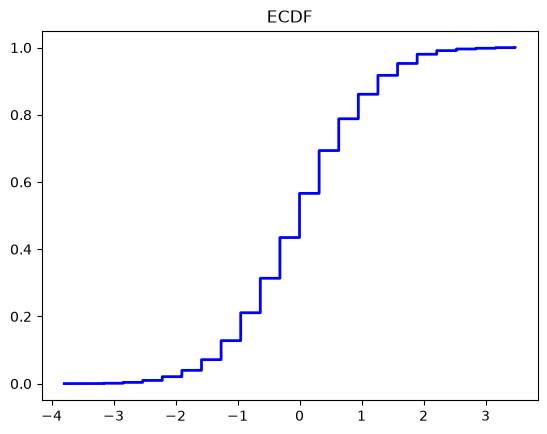

In [83]:
n = 40
p = 0.5
b = 5000

heads_list = rng.binomial(n=n, p=p, size=b)
z_list = (heads_list - (n*p)) / np.sqrt((n*p*(1-p)))

x, y = ecdf_xy(z_list)  
plt.step(x, y, where='post', color='blue', lw=2)
plt.title("ECDF")
#plt.xlabel("successes")
#plt.ylabel("cumulative probability")
plt.show()

5.

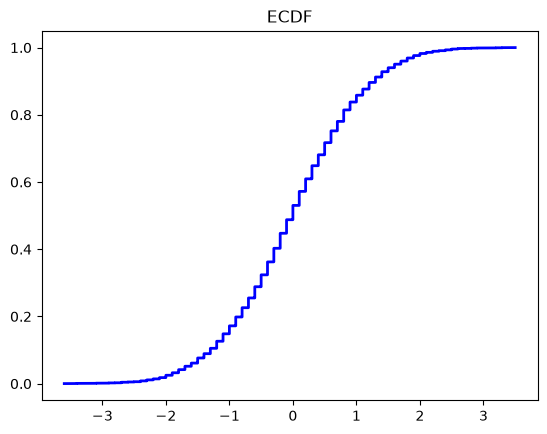

In [84]:
n = 400
p = 0.5
b = 5000

heads_list = rng.binomial(n=n, p=p, size=b)
z_list = (heads_list - (n*p)) / np.sqrt((n*p*(1-p)))

x, y = ecdf_xy(z_list)  
plt.step(x, y, where='post', color='blue', lw=2)
plt.title("ECDF")
#plt.xlabel("successes")
#plt.ylabel("cumulative probability")
plt.show()

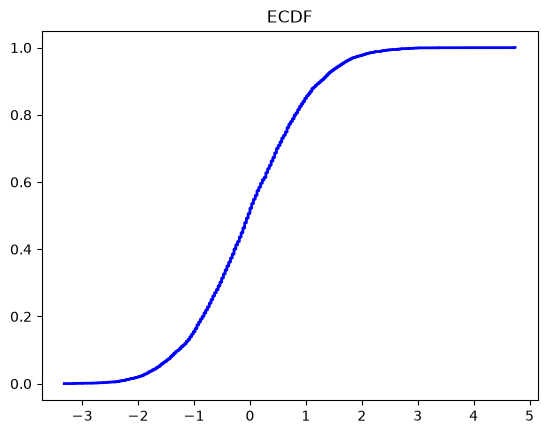

In [85]:
n = 4000
p = 0.5
b = 5000

heads_list = rng.binomial(n=n, p=p, size=b)
z_list = (heads_list - (n*p)) / np.sqrt((n*p*(1-p)))

x, y = ecdf_xy(z_list)  
plt.step(x, y, where='post', color='blue', lw=2)
plt.title("ECDF")
#plt.xlabel("successes")
#plt.ylabel("cumulative probability")
plt.show()

As we increase $n$, this ECDF approaches a Normal Distribution.

6.

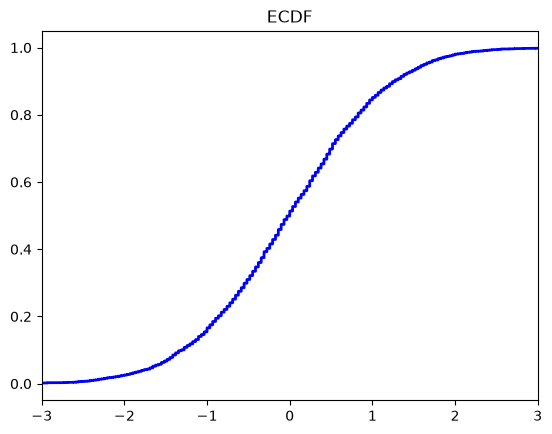

In [86]:
# adjusting p values
n = 4000
p = 0.7
b = 5000

heads_list = rng.binomial(n=n, p=p, size=b)
z_list = (heads_list - (n*p)) / np.sqrt((n*p*(1-p)))

x, y = ecdf_xy(z_list)  
plt.step(x, y, where='post', color='blue', lw=2)
plt.title("ECDF")
plt.xlim(-3,3)
#plt.xlabel("successes")
#plt.ylabel("cumulative probability")
plt.show()

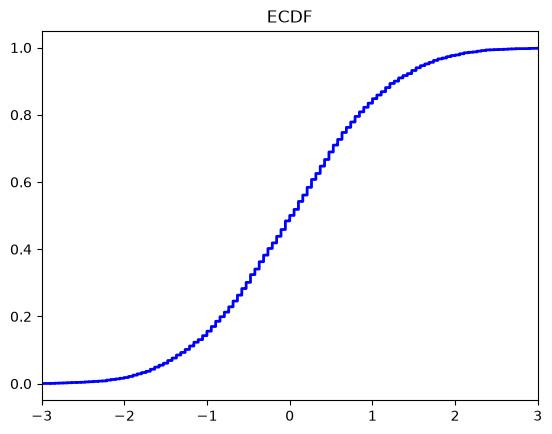

In [87]:
n = 4000
p = 0.1
b = 5000

heads_list = rng.binomial(n=n, p=p, size=b)
z_list = (heads_list - (n*p)) / np.sqrt((n*p*(1-p)))

x, y = ecdf_xy(z_list)  
plt.step(x, y, where='post', color='blue', lw=2)
plt.title("ECDF")
plt.xlim(-3,3)
#plt.xlabel("successes")
#plt.ylabel("cumulative probability")
plt.show()

Adjusting $p$ does not change the distribution from a normal distribution as we are essentially standardizing by the new mean and standard deviation.

However, as we adjust $p$ lower we do notice that step sizes become more pronounced in our ECDF because we have less instances of successes.

## Q4. ##

1.

In [88]:
r = 0.5 #arbitrary 
dt = 1e-3

def simulate_termination(r, dt):
    p = r*dt

    if p > 1:
        raise ValueError("probability is higher than 1")
    
    period = 0

    while True:
        period += 1
        random = rng.random()
        if random < p:
            return period

2.

In [89]:
time_taken = simulate_termination(r, dt) * dt
time_taken

0.115

3.

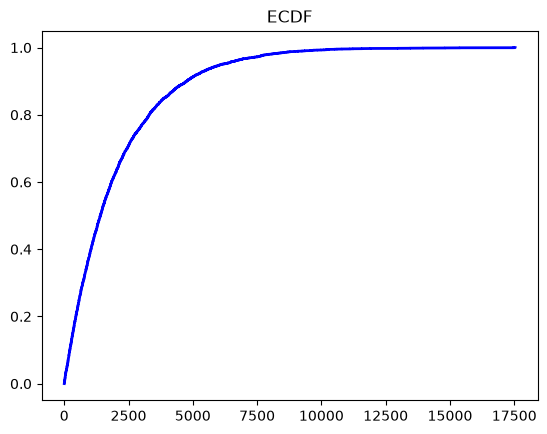

In [90]:
r = 0.5
dt = 1e-3
B = 5000

results = [simulate_termination(r,dt) for i in range(B)]

x, y = ecdf_xy(results)  
plt.step(x, y, where='post', color='blue', lw=2)
plt.title("ECDF")
plt.show()

4.

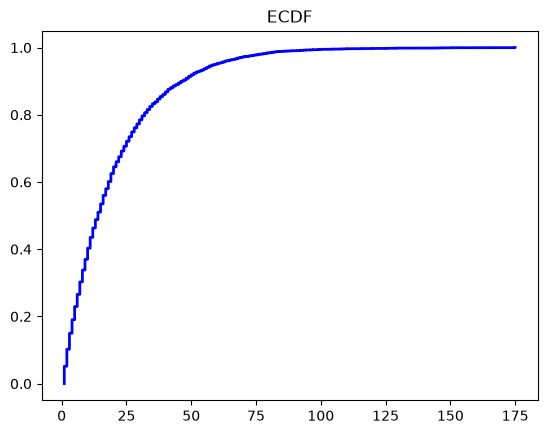

In [91]:
# showing ECDF at a higher value of dt,
r = 0.5
dt = 1e-1
B = 5000

results = [simulate_termination(r,dt) for i in range(B)]

x, y = ecdf_xy(results)  
plt.step(x, y, where='post', color='blue', lw=2)
plt.title("ECDF")
plt.show()

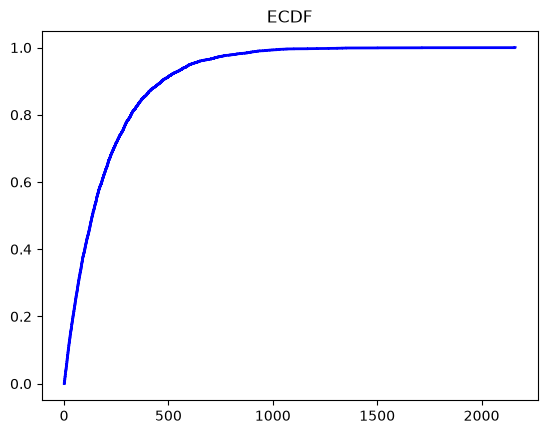

In [92]:
r = 0.5
dt = 1e-2
B = 5000

results = [simulate_termination(r,dt) for i in range(B)]

x, y = ecdf_xy(results)  
plt.step(x, y, where='post', color='blue', lw=2)
plt.title("ECDF")
plt.show()

As $dt$ goes to zero, this approaches an Exponential Distribution.

5.


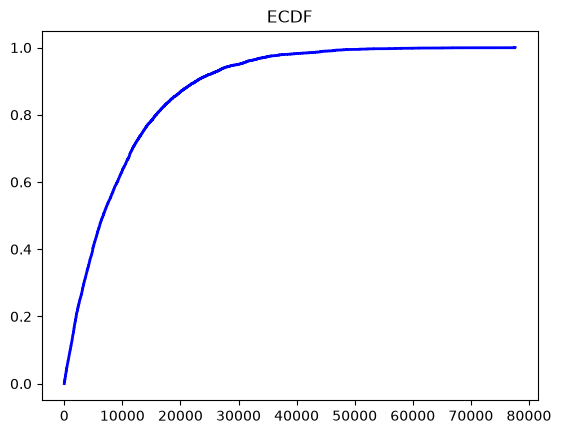

In [93]:
r = 0.1
dt = 1e-3
B = 5000

results = [simulate_termination(r,dt) for i in range(B)]

x, y = ecdf_xy(results)  
plt.step(x, y, where='post', color='blue', lw=2)
plt.title("ECDF")
plt.show()

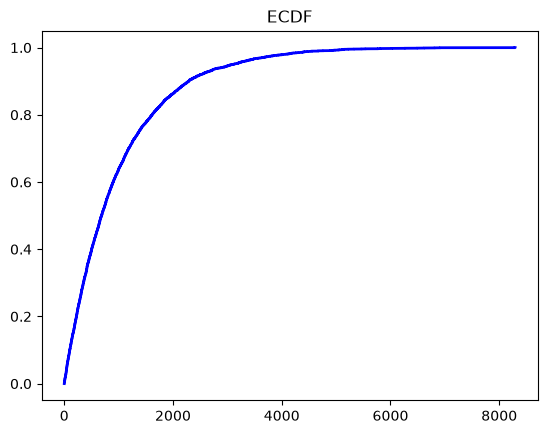

In [94]:
r = 1
dt = 1e-3
B = 5000

results = [simulate_termination(r,dt) for i in range(B)]

x, y = ecdf_xy(results)  
plt.step(x, y, where='post', color='blue', lw=2)
plt.title("ECDF")
plt.show()

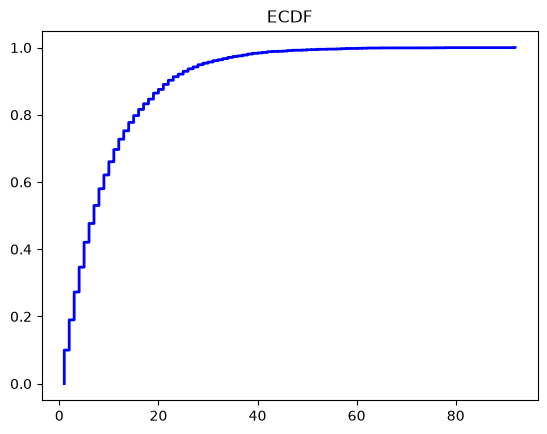

In [95]:
r = 100
dt = 1e-3
B = 5000

results = [simulate_termination(r,dt) for i in range(B)]

x, y = ecdf_xy(results)  
plt.step(x, y, where='post', color='blue', lw=2)
plt.title("ECDF")
plt.show()

As $r$ increases our probability of termination increases, our ECDF more quickly goes to 1. For example with an r = 0.1, the ECDF appears to go to 1 around 50,000 time units versus an r = 100 where the ECDF appears to go to 1 around 40 time units.

AI Statement: We used ChatGPT to help us understand our "TypeError: object of type 'float' has no len()" error when using np.random.default_rng().choice().